# Segmentation d'Images par Réseaux de Neurones
**Cours :** Optimisation Stochastique (P. Weiss)

**Auteurs :** BOULAALAM El-Mehdi, Matthias Herla
## Objectif du NoteBook
Comparer différents algorithmes d'optimisation (SGD, Adam, RMSProp) pour la tâche de segmentation d'images texturées synthétiques.
## Plan
- Génération données synthétiques
- CNN baseline
- Comparaison optimiseurs (SGD, Adam, RMSProp)
- Impact Learning Rate
- Architecture U-Net vs CNN
- Évaluation qualitative (visualisations, cartes d'erreur)


---

# 1. Configuration et Génération de Données

### 1.1 Imports et Configuration GPU

In [1]:
!pip install torch
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
dtype = torch.cuda.FloatTensor if use_cuda else torch.FloatTensor
print(f"Exécution sur : {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.7/915.7 MB 66.5 MB/s  0:00:10m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 110.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 76.1 MB/s  0:00:05m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 104.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 101.4 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 49.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 81.0 MB/s  0:00:07m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 94.4 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 44.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 49.1 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 88.8 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 1

## Fonction de Normalisation

In [2]:
def rescale_01(y_t):
    y_t -= y_t.amin(dim = (2,3),keepdim=True)
    y_t /= y_t.amax(dim = (2,3),keepdim=True)
    return y_t

### 1.2 Génération des Données Synthétiques

**Principe** : Images composées de 2 textures différentes (processus gaussiens) avec frontière lisse.

**Analyse des paramètres :**
- sigma1, sigma2 : contrôlent les statistiques des textures
- sigma : contrôle la régularité des frontières

In [3]:
def generate_data(batch_size, size_image, sigma1, sigma2, sigma):

    xs = torch.linspace(-size_image/2, size_image/2, size_image).type(dtype)
    ys = torch.linspace(-size_image/2, size_image/2, size_image).type(dtype)

    # The type of x,y below is automatically set to dtype, because xs, ys are of type dtype
    x, y = torch.meshgrid(xs, ys, indexing='xy')

    # Defining 4 Gaussian
    g = torch.exp(-(x**2+y**2)/(2*sigma**2))
    g = g/torch.sum(g)

    g1 = torch.exp(-(x**2+y**2)/(2*sigma1**2))
    g1 = g1/torch.sum(g1)

    g2 = torch.exp(-(x**2+y**2)/(2*sigma2**2))
    g2 = g2/torch.sum(g2)

    g3 = torch.exp(-(x**2+y**2)/(2*1**2))
    g3 = g3/torch.sum(g3)

    # We define a random smooth partition
    b = torch.randn(batch_size,1,size_image,size_image).type(dtype)
    gp = F.conv2d(b, g[None,None], padding = 'same')
    omega1 = gp>0 #Seuillage

    # We define two Gaussian random processes with differents statistics
    b1 = torch.randn(batch_size,1,size_image,size_image).type(dtype)
    gp1 = F.conv2d(b1, g1[None,None], padding = 'same')
    b2 = torch.randn(batch_size,1,size_image,size_image).type(dtype)
    gp2 = F.conv2d(b2, g2[None,None], padding = 'same')

    # Now we put each process at the right place
    u = gp1*omega1 + gp2*(~omega1)
    # We smooth the result to avoid having a jump at the interfaces
    u =  F.conv2d(u, g3[None,None], padding = 'same')
    u = rescale_01(u)

    return u, omega1.type(dtype)

### 1.3 Interpretation des Parametres

/tmp/ipykernel_952/4181913714.py:24: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  gp = F.conv2d(b, g[None,None], padding = 'same')


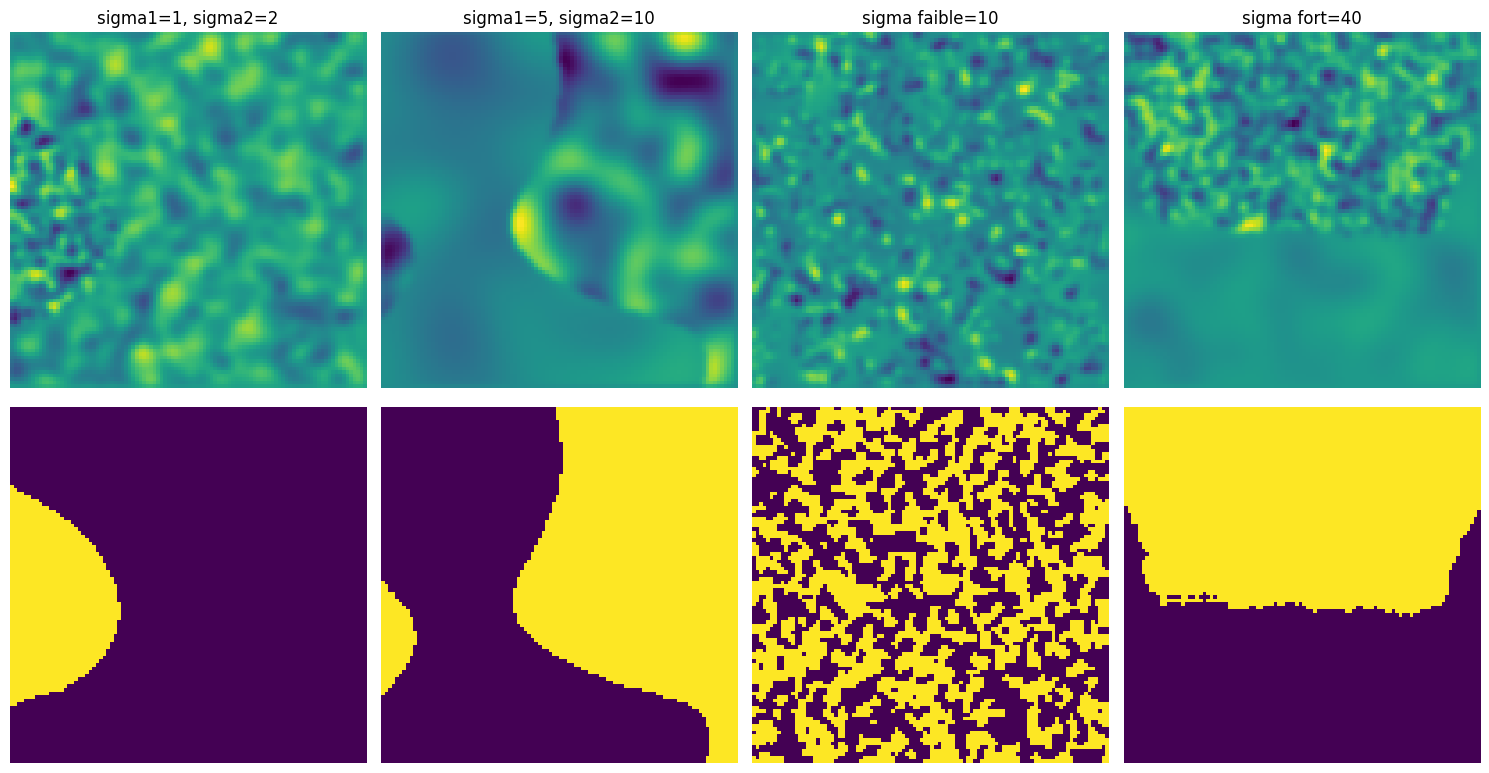

In [4]:
import matplotlib.pyplot as plt

# Tester différents paramètres
params = [
    (1, 2, 20, "sigma1=1, sigma2=2"),
    (5, 10, 20, "sigma1=5, sigma2=10"),
    (1, 5, 1, "sigma faible=10"),
    (1, 5, 40, "sigma fort=40")
]

fig, axes = plt.subplots(2, 4, figsize=(15, 8))

for idx, (s1, s2, s, label) in enumerate(params):
    u, omega1 = generate_data(1, 100, s1, s2, s)

    # Afficher l'image
    axes[0, idx].imshow(u[0,0].cpu().detach().numpy())
    axes[0, idx].set_title(label)
    axes[0, idx].axis('off')

    # Afficher la partition
    axes[1, idx].imshow(omega1[0,0].cpu().detach().numpy())
    axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

**Conclusion:**

sigma1 : Définit la taille du grain (la corrélation) de la texture dans la zone Ω1​.
C'est ce qui rend cette zone visuellement spécifique.

sigma2 : Définit la taille du grain de la texture dans la zone Ω2​

sigma (le bruit global) : En général, ce paramètre  ajoute un bruit blanc additif par-dessus l'image finale. C'est comme rajouter des "parasites" sur une photo : plus sigma est élevé, plus il est difficile de distinguer les textures sigma1 et sigma2

Le problème d’identification devient difficile dès que les textures commencent à se ressembler, c'est-à-dire quand σ1​ est proche de σ2​, ainsi qu'un choix d'un σ petit produit.

# 2. Architectures de Réseaux de Neurones

### 2.1 CNN Baseline (Architecture Demandée)
### Architecture

Le reseau possede 4 couches de convolution :
- 3 couches conv (5x5) avec ReLU + BatchNorm
- 1 couche finale avec Sigmoid pour sortie binaire [0,1]

Rôle du Sigmoid : normalisation des sorties entre [0,1] pour probabilités

In [5]:
class my_first_CNN(nn.Module):
    def __init__(self, num_channels=16, bias=True):
        super(my_first_CNN, self).__init__()

        self.activation = nn.ReLU()
        self.kernel_size = 5
        self.pad = int((self.kernel_size - 1) / 2)

        self.conv1 = nn.Sequential(
            nn.Conv2d(1, num_channels, kernel_size=5, padding=2, bias=bias),
            nn.ReLU(),
            nn.BatchNorm2d(num_channels)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(num_channels, num_channels, kernel_size=5, padding=2, bias=bias),
            nn.ReLU(),
            nn.BatchNorm2d(num_channels)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(num_channels, num_channels, kernel_size=5, padding=2, bias=bias),
            nn.ReLU(),
            nn.BatchNorm2d(num_channels)
        )

        self.out = nn.Conv2d(num_channels, 1, kernel_size=5, padding=2, bias=bias)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        return torch.sigmoid(self.out(x))

### 2.2 Visualisation du Modele

In [6]:
predictor = my_first_CNN(num_channels=16,bias=True).type(dtype)
predictor.to(device) # We decide whether the network operates on GPU or CPU
print(predictor) # We can display the model


my_first_CNN(
  (activation): ReLU()
  (conv1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): Sequential(
    (0): Conv2d(16, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (out): Conv2d(16, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
)


# 3. Comparaison des Algorithmes d'Optimisation

### 3.1 But de cette partie

La comparaison des algorithmes d'optimisation repose sur une méthodologie équitable : chaque optimiseur (SGD, SGD+Momentum, RMSProp, Adam) est testé avec un nouveau modèle CNN identique mais ré-initialisé aléatoirement. Les learning rates sont adaptés par algorithme (0.01 pour SGD, 0.001 pour Adam/RMSProp).

Les métriques évaluées incluent la loss MSE sur l'entraînement et la validation, le temps d'exécution, et l'évolution de la convergence. La validation est effectuée tous les 100 itérations sur un ensemble fixe de 50 images.


In [7]:
# Parametres d'entrainement
batch_size = 10
size_image = 100
sigma1 = 1.
sigma2 = 2.
sigma = size_image/5.
niter_train = 5000  # Nombre total d'iterations
display_it = 500    # Affichage tous les 500 iterations

# Generer un dataset de validation fixe
n_val = 50
x_val, y_val = generate_data(n_val, size_image, sigma1, sigma2, sigma)
x_val = x_val.to(device)
y_val = y_val.to(device)

### 3.2 Entrainement du Modele CNN
A chaque iteration :
1. Generer un nouveau batch d'images aleatoires (simulation de dataset infini)
2. Forward : passer x dans le reseau pour obtenir prediction
3. Calculer loss (MSE entre prediction et verite)
4. Backward : calculer gradients par backpropagation
5. Step : mettre a jour les poids avec l'optimiseur

On va comparer differents optimiseurs sur le CNN simple avec :
- Memes parametres (batch_size, epochs, learning_rate)
- Meme fonction de perte (MSE)
- Dataset fixe pour comparaison equitable

In [8]:
import time

# Configurations a tester
configs = [
    ("SGD", 0.001, optim.SGD, {}),
    ("SGD+Momentum", 0.0001, optim.SGD, {'momentum': 0.9}),
    ("RMSProp", 0.001, optim.RMSprop, {}),
    ("Adam", 0.001, optim.Adam, {})
]

results = {}

for name, lr, optim_class, kwargs in configs:
    print(f"Entrainement avec {name} (LR={lr})")

    # Nouveau modele pour chaque test
    model = my_first_CNN(num_channels=16, bias=True).type(dtype).to(device)
    optimizer = optim_class(model.parameters(), lr=lr, **kwargs)

    train_losses = []
    val_losses = []

    start_time = time.time()

    i = 0
    while i < niter_train:
        i += 1

        # Generer batch d'entrainement
        x, omega1 = generate_data(batch_size, size_image, sigma1, sigma2, sigma)

        # Forward
        optimizer.zero_grad()
        prediction = model(x)

        # Loss
        loss = torch.sum((prediction - omega1)**2) / batch_size

        # Backward + step
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        # Validation tous les 100 iterations
        if i % 100 == 0:
            model.eval()
            with torch.no_grad():
                val_pred = model(x_val)
                val_loss = torch.sum((val_pred - y_val)**2) / n_val
                val_losses.append(val_loss.item())
            model.train()

        # Affichage
        if i % display_it == 0:
            print(f"Iter {i}/{niter_train} - Train Loss: {loss.item():.4f} - Val Loss: {val_losses[-1]:.4f}")

    elapsed = time.time() - start_time
    print(f"Temps total: {elapsed:.1f}s")

    results[name] = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'time': elapsed,
        'final_train_loss': train_losses[-1],
        'final_val_loss': val_losses[-1]
    }

Entrainement avec SGD (LR=0.001)
Iter 500/5000 - Train Loss: 215.9944 - Val Loss: 248.5083
Iter 1000/5000 - Train Loss: 143.3179 - Val Loss: 161.9094
Iter 1500/5000 - Train Loss: 144.7212 - Val Loss: 145.6786
Iter 2000/5000 - Train Loss: 108.4876 - Val Loss: 106.7058
Iter 2500/5000 - Train Loss: 210.5619 - Val Loss: 239.3092
Iter 3000/5000 - Train Loss: 138.4618 - Val Loss: 146.8595
Iter 3500/5000 - Train Loss: 128.3172 - Val Loss: 121.1750
Iter 4000/5000 - Train Loss: 102.7556 - Val Loss: 92.6665
Iter 4500/5000 - Train Loss: 115.1634 - Val Loss: 144.5757
Iter 5000/5000 - Train Loss: 119.1713 - Val Loss: 196.1573
Temps total: 46.0s
Entrainement avec SGD+Momentum (LR=0.0001)
Iter 500/5000 - Train Loss: 170.6310 - Val Loss: 266.0992
Iter 1000/5000 - Train Loss: 105.0482 - Val Loss: 108.6953
Iter 1500/5000 - Train Loss: 88.5076 - Val Loss: 111.9047
Iter 2000/5000 - Train Loss: 77.9916 - Val Loss: 111.3376
Iter 2500/5000 - Train Loss: 98.3260 - Val Loss: 74.2432
Iter 3000/5000 - Train Loss

### 3.3 Interpretation des Resultats

- SGD (LR=0.001) : Convergence lente et limitée. La loss diminue mais finit assez haut . L'absence d'adaptation du pas freine l'apprentissage.

- SGD+Momentum (LR=0.0001) : Convergence réussie. En divisant le LR par 10, le modèle devient stable et descend efficacement vers une loss de ~49. Cela démontre que le Momentum est très sensible au taux d'apprentissage : trop élevé (0.001), il diverge ; bien réglé (0.0001), il surpasse le SGD simple

- RMSProp (LR=0.001) : Excellente performance. Descente rapide et stable vers une loss de ~40. L'ajustement automatique du learning rate est ici très efficace.

- Adam (LR=0.001) : Meilleur résultat. Convergence rapide vers la loss la plus basse (~39). C'est l'algorithme le plus robuste pour cette tâche de segmentation complexe


**NB** : Dans la fonction generate_data, on a utilisé des paramètres sigma1, sigma2 et sigma ce qui signifie que les images contiennent du bruit stochastique. Même si le modèle devenait "parfait", il ne pourrait jamais prédire la valeur exacte de chaque pixel bruité parcequ il existe une limite théorique minimale appelée erreur de Bayes. La perte ne descendra jamais en dessous de la variance de ce bruit.. C'est pour sa que la loss ne tombe pas a 0 parceuqe si c'etait le cas, ça sera forcement un problème d'overfitting

# 4. Impact du Learning Rate

### 4.1 But de cette partie
On essaye  d'identifier le taux d'apprentissage (learning rate) optimal pour l'algorithme Adam, en comparant l'impact de différentes échelles (10−4 à 10−1) sur la rapidité et la stabilité de la convergence.


Test avec LR=0.0001

Test avec LR=0.001

Test avec LR=0.01

Test avec LR=0.1


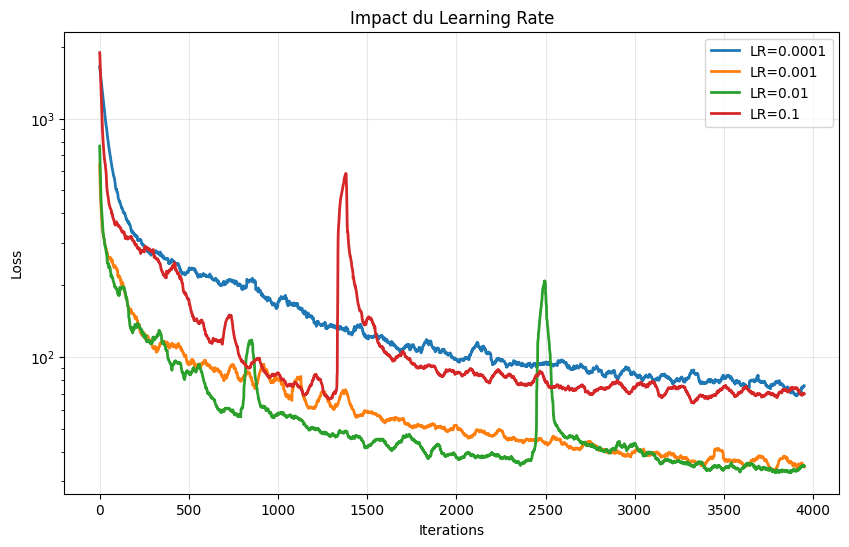

In [9]:
best_algo = "Adam"

learning_rates = [0.0001, 0.001, 0.01, 0.1]
results_lr = {}

for lr in learning_rates:
    print(f"\nTest avec LR={lr}")

    model = my_first_CNN(num_channels=16, bias=True).type(dtype).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []

    i = 0
    while i < 4000:  # Moins d'iterations pour gagner du temps
        i += 1

        x, omega1 = generate_data(batch_size, size_image, sigma1, sigma2, sigma)

        optimizer.zero_grad()
        prediction = model(x)
        loss = torch.sum((prediction - omega1)**2) / batch_size
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    results_lr[lr] = train_losses

# Visualisation
plt.figure(figsize=(10, 6))
for lr in learning_rates:
    window = 50
    smooth = np.convolve(results_lr[lr], np.ones(window)/window, mode='valid')
    plt.plot(smooth, label=f'LR={lr}', linewidth=2)

plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Impact du Learning Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

### 4.2 Interpretation Learning Rate

**LR=0.0001** (bleu) : Trop faible. L'apprentissage est "trop prudent". Le modèle finirait peut-être par atteindre le même résultat que LR=0.001, mais il lui faudrait 10 ou 20 fois plus de temps de calcul.

**LR=0.001** (jaune) : L'optimum (Sweet Spot). C'est le meilleur compromis : la descente est rapide et le modèle atteint le niveau d'erreur le plus bas en 4000 itérations.

**LR=0.01** (vert) : Sub-optimal. C'est un peu trop rapide pour permettre une convergence précise. Le modèle "rebondit" autour du minimum sans jamais l'atteindre vraiment.

**LR=0.1** (rouge) : Trop élevé. L'optimiseur fait des "pas" trop grands et saute par-dessus les minima locaux. Le modèle diverge ou reste bloqué dans une zone de haute erreur.

**Conclusion** :
L'optimiseur Adam calcule des taux d'apprentissage adaptatifs pour chaque paramètre, mais il reste extrêmement sensible au Learning Rate de base
- **Choix : LR=0.001** pour Adam (meilleur compromis)

---

# 5. Recherche du meilleur prédicteur : Architecture U-Net


Pour répondre à l'objectif d'obtenir le meilleur prédicteur possible pour identifier l'ensemble ω1​ , nous implémentons ici une architecture U-Net. Ce modèle plus sophistiqué utilise des blocs DoubleConv intégrant de la Batch Normalization pour stabiliser l'apprentissage et une structure encodeur-décodeur avec connexions sautées (skip connections) pour maximiser la précision de la segmentation sous contrainte de temps

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = DoubleConv(1, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec3 = DoubleConv(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec2 = DoubleConv(128, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.dec1 = DoubleConv(64, 32)

        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))

        # Ajuster tailles avant concat
        d3 = self.up3(b)
        d3 = F.interpolate(d3, size=e3.shape[2:], mode='bilinear', align_corners=False)
        d3 = self.dec3(torch.cat([e3, d3], 1))

        d2 = self.up2(d3)
        d2 = F.interpolate(d2, size=e2.shape[2:], mode='bilinear', align_corners=False)
        d2 = self.dec2(torch.cat([e2, d2], 1))

        d1 = self.up1(d2)
        d1 = F.interpolate(d1, size=e1.shape[2:], mode='bilinear', align_corners=False)
        d1 = self.dec1(torch.cat([e1, d1], 1))

        return torch.sigmoid(self.out(d1))

### 5.1 Métriques d'évaluation de la segmentation
On définit les fonctions IoU (Intersection over Union) et Dice, des métriques standards utilisées pour évaluer quantitativement la précision de la segmentation de l'ensemble ω1​ par rapport à la vérité terrain fv

In [ ]:
def compute_iou(pred, target, threshold=0.5):
    pred_binary = (pred > threshold).float()
    target_binary = (target > threshold).float()

    intersection = (pred_binary * target_binary).sum()
    union = pred_binary.sum() + target_binary.sum() - intersection

    return (intersection / (union + 1e-6)).item()

def compute_dice(pred, target, threshold=0.5):
    pred_binary = (pred > threshold).float()
    target_binary = (target > threshold).float()

    intersection = (pred_binary * target_binary).sum()

    return (2 * intersection / (pred_binary.sum() + target_binary.sum() + 1e-6)).item()

### 5.2 Procedure d'entraînement sous contrainte temporelle


In [ ]:
def train_model(model, optimizer, duration_minutes=2):
    import time

    train_losses = []
    val_losses = []
    ious = []
    dices = []

    start_time = time.time()
    i = 0

    print(f"Debut entrainement - Duree: {duration_minutes} min")

    while (time.time() - start_time) < duration_minutes * 60:
        i += 1

        x, y = generate_data(batch_size, size_image, sigma1, sigma2, sigma)

        optimizer.zero_grad()
        pred = model(x)
        loss = torch.sum((pred - y)**2) / batch_size
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        if i % 100 == 0:
            model.eval()
            with torch.no_grad():
                val_pred = model(x_val)
                val_loss = torch.sum((val_pred - y_val)**2) / n_val
                val_losses.append(val_loss.item())

                iou = compute_iou(val_pred, y_val)
                dice = compute_dice(val_pred, y_val)
                ious.append(iou)
                dices.append(dice)

                # Print toutes les 100 iterations
                print(f"Iter {i} - Loss: {loss.item():.2f} - Val: {val_loss.item():.2f} - IoU: {iou:.3f}")

            model.train()

    elapsed = time.time() - start_time
    print(f"Termine - {i} iterations en {elapsed:.1f}s")

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'ious': ious,
        'dices': dices,
        'time': elapsed,
        'iterations': i
    }

### 5.3 Comparaison finale : CNN simple vs U-Net

In [ ]:
# CNN
model_cnn = my_first_CNN(num_channels=16, bias=True).type(dtype).to(device)
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=0.001)
results_cnn = train_model(model_cnn, optimizer_cnn, duration_minutes=2)

# U-Net
model_unet = UNet().type(dtype).to(device)
optimizer_unet = optim.Adam(model_unet.parameters(), lr=0.001)
results_unet = train_model(model_unet, optimizer_unet, duration_minutes=2)

Debut entrainement - Duree: 2 min
Iter 100 - Loss: 212.52 - Val: 238.02 - IoU: 0.945
Iter 200 - Loss: 290.52 - Val: 167.11 - IoU: 0.962
Iter 300 - Loss: 159.55 - Val: 122.82 - IoU: 0.971
Iter 400 - Loss: 90.08 - Val: 198.12 - IoU: 0.956
Iter 500 - Loss: 121.51 - Val: 155.55 - IoU: 0.963
Iter 600 - Loss: 72.49 - Val: 109.66 - IoU: 0.974
Iter 700 - Loss: 78.49 - Val: 89.86 - IoU: 0.978
Iter 800 - Loss: 86.90 - Val: 200.94 - IoU: 0.960
Iter 900 - Loss: 68.59 - Val: 67.98 - IoU: 0.983
Iter 1000 - Loss: 42.00 - Val: 69.25 - IoU: 0.983
Iter 1100 - Loss: 109.89 - Val: 90.98 - IoU: 0.978
Iter 1200 - Loss: 73.48 - Val: 76.44 - IoU: 0.982
Iter 1300 - Loss: 84.48 - Val: 65.23 - IoU: 0.984
Iter 1400 - Loss: 58.15 - Val: 60.34 - IoU: 0.986
Iter 1500 - Loss: 51.30 - Val: 94.96 - IoU: 0.978
Iter 1600 - Loss: 45.79 - Val: 58.28 - IoU: 0.986
Iter 1700 - Loss: 55.91 - Val: 55.68 - IoU: 0.986
Iter 1800 - Loss: 46.49 - Val: 54.19 - IoU: 0.987
Iter 1900 - Loss: 51.55 - Val: 52.76 - IoU: 0.987
Iter 2000 - L

### 5.4 Analyse comparative des performances

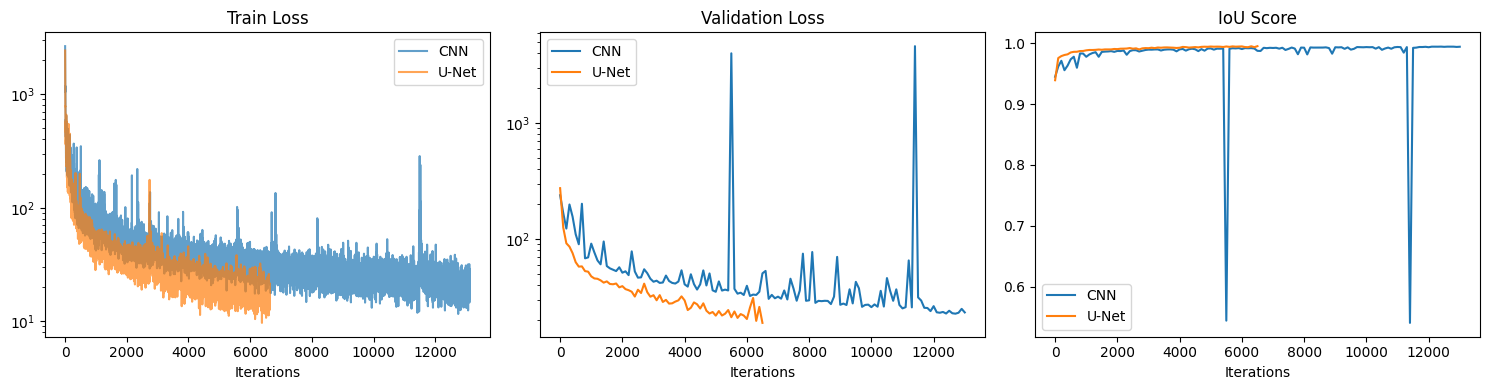

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Train loss
axes[0].plot(results_cnn['train_losses'], label='CNN', alpha=0.7)
axes[0].plot(results_unet['train_losses'], label='U-Net', alpha=0.7)
axes[0].set_title('Train Loss')
axes[0].set_xlabel('Iterations')
axes[0].legend()
axes[0].set_yscale('log')

# Val loss
val_iters_cnn = range(0, len(results_cnn['val_losses'])*100, 100)
val_iters_unet = range(0, len(results_unet['val_losses'])*100, 100)
axes[1].plot(val_iters_cnn, results_cnn['val_losses'], label='CNN')
axes[1].plot(val_iters_unet, results_unet['val_losses'], label='U-Net')
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Iterations')
axes[1].legend()
axes[1].set_yscale('log')

# IoU
axes[2].plot(val_iters_cnn, results_cnn['ious'], label='CNN')
axes[2].plot(val_iters_unet, results_unet['ious'], label='U-Net')
axes[2].set_title('IoU Score')
axes[2].set_xlabel('Iterations')
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
print("\nComparaison finale:")
print(f"{'Métrique':<20} {'CNN':<15} {'U-Net':<15}")
print("-" * 50)
print(f"{'Temps (s)':<20} {results_cnn['time']:<15.1f} {results_unet['time']:<15.1f}")
print(f"{'Iterations':<20} {results_cnn['iterations']:<15} {results_unet['iterations']:<15}")
print(f"{'Train Loss finale':<20} {results_cnn['train_losses'][-1]:<15.2f} {results_unet['train_losses'][-1]:<15.2f}")
print(f"{'Val Loss finale':<20} {results_cnn['val_losses'][-1]:<15.2f} {results_unet['val_losses'][-1]:<15.2f}")
print(f"{'IoU finale':<20} {results_cnn['ious'][-1]:<15.3f} {results_unet['ious'][-1]:<15.3f}")
print(f"{'Dice finale':<20} {results_cnn['dices'][-1]:<15.3f} {results_unet['dices'][-1]:<15.3f}")


Comparaison finale:
Métrique             CNN             U-Net          
--------------------------------------------------
Temps (s)            120.0           120.0          
Iterations           13121           6632           
Train Loss finale    20.70           13.83          
Val Loss finale      23.21           18.85          
IoU finale           0.994           0.995          
Dice finale          0.997           0.998          


### 5.5  Conclusion
Bien que le U-Net soit plus lourd (il réalise deux fois moins d'itérations que le CNN en 120 secondes), il est nettement plus performant :

- Précision supérieure : Le U-Net atteint une IoU (0.995) et un Dice (0.998) plus élevés, ainsi qu'une perte de validation plus faible (18.85 contre 23.21).

-  Stabilité de l'apprentissage : Les graphiques montrent que le CNN subit des chutes brutales d'IoU (pics d'instabilité), tandis que le U-Net reste stable et régulier.

-    Efficacité par itération : Malgré sa complexité, le U-Net apprend "mieux" avec moins de mises à jour de poids grâce à son architecture encodeur-décodeur et ses skip connections qui préservent mieux les détails spatiaux des textures.

# 6.Évaluation qualitative et comparaison visuelle

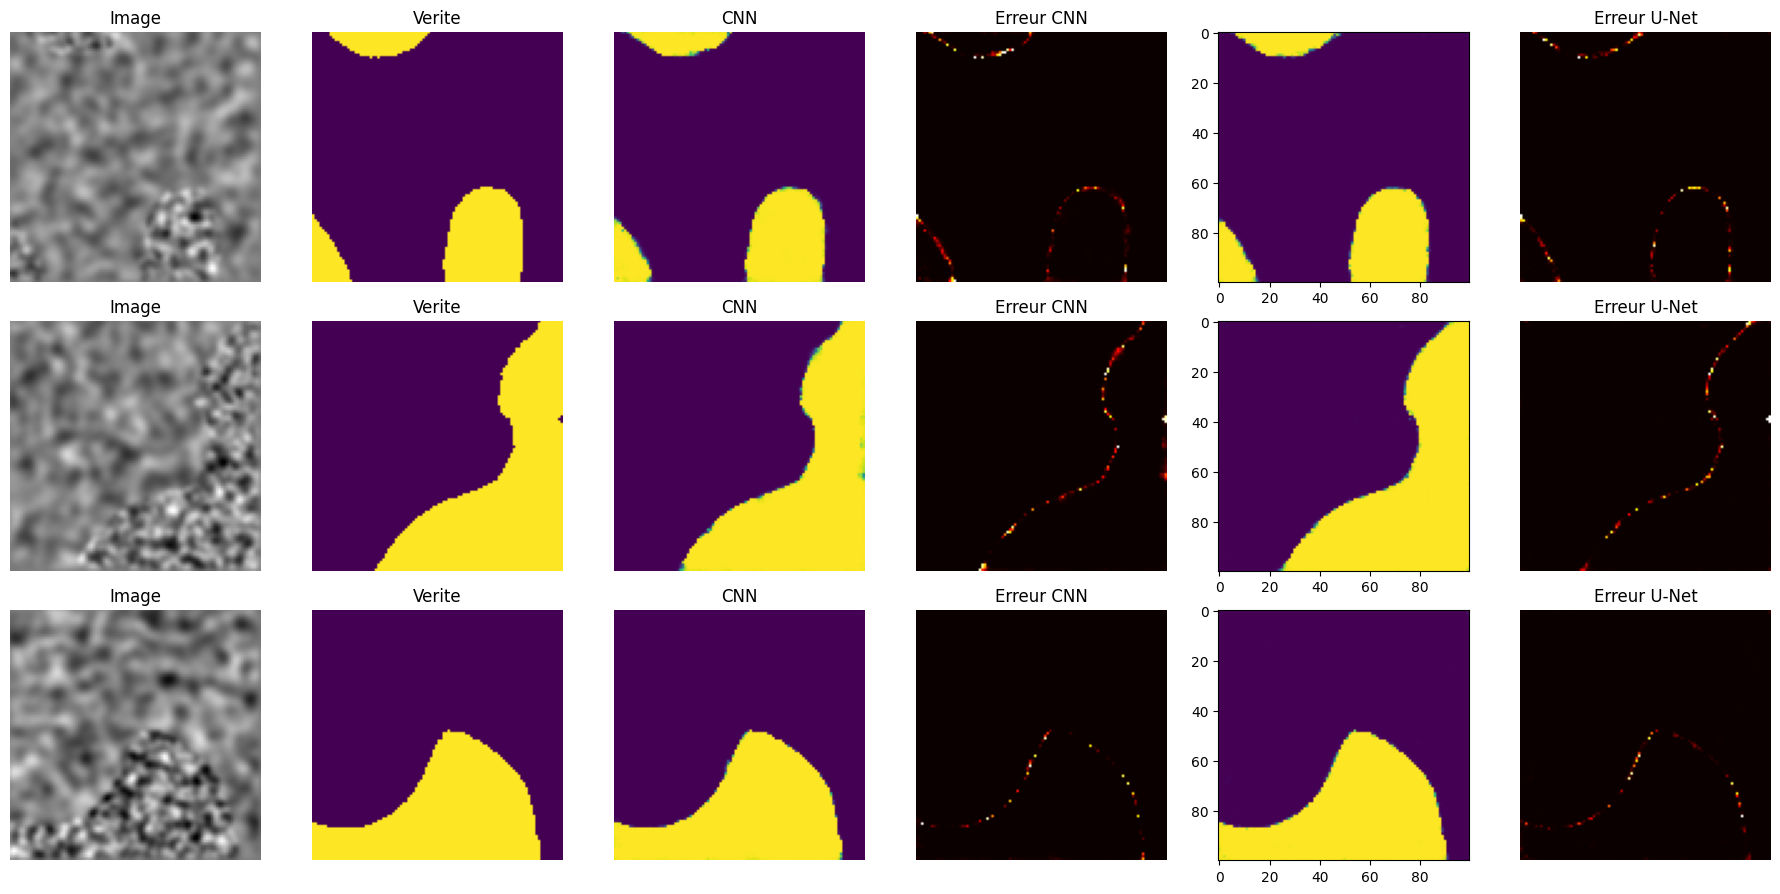

In [ ]:
x_test, y_test = generate_data(3, size_image, sigma1, sigma2, sigma)

model_cnn.eval()
model_unet.eval()
with torch.no_grad():
    pred_cnn = model_cnn(x_test)
    pred_unet = model_unet(x_test)

fig, axes = plt.subplots(3, 6, figsize=(18, 9))

for i in range(3):
    # Image
    axes[i, 0].imshow(x_test[i, 0].cpu(), cmap='gray')
    axes[i, 0].set_title('Image')
    axes[i, 0].axis('off')

    # Vérité
    axes[i, 1].imshow(y_test[i, 0].cpu(), cmap='viridis')
    axes[i, 1].set_title('Verite')
    axes[i, 1].axis('off')

    # CNN pred
    axes[i, 2].imshow(pred_cnn[i, 0].cpu(), cmap='viridis')
    axes[i, 2].set_title('CNN')
    axes[i, 2].axis('off')

    # CNN erreur
    error_cnn = torch.abs(pred_cnn[i, 0] - y_test[i, 0]).cpu()
    axes[i, 3].imshow(error_cnn, cmap='hot')
    axes[i, 3].set_title('Erreur CNN')
    axes[i, 3].axis('off')

    # U-Net pred
    axes[i, 4].imshow(pred_unet[i, 0].cpu(), cmap='viridis')

    # U-Net erreur
    error_unet = torch.abs(pred_unet[i, 0] - y_test[i, 0]).cpu()
    axes[i, 5].imshow(error_unet, cmap='hot')
    axes[i, 5].set_title('Erreur U-Net')
    axes[i, 5].axis('off')

plt.tight_layout()
plt.show()

On visualise concretement les performances de segmentation sur des images de test. L'affichage des cartes d'erreur (en chaud/froid) met en évidence la précision des modèles sur les contours et confirme la supériorité du U-Net pour localiser fidèlement l'ensemble ω1​.